In [1]:
import os
import stark as sk
import numpy as np
import pandas as pd


In [2]:
hdata = sk.HData.read_h5ad('cycle.h5ad')

In [3]:
sk.tl.aggregate_metacell_mat(hdata, force_aggregate=False)


Aggregating @ 500000: 100%|██████████| 30/30 [00:03<00:00,  9.87it/s]


✅ 全量聚合完成！
   可通过 base_on='mat' 方式可视化的分辨率: [50000, 500000, 1000000]
   调用示例: sk.pl.plot_metacell_heatmap(hdata, ..., resolution=50000, base_on='mat')


['G1', 'early-S', 'late-S-G2']
[6, 10, 16, 21]
['G1', 'early-S', 'late-S-G2']
['4', '19', '20', '42', '49', '51', '57', '61', '81', '86', '88', '98', '100', '101', '103', '104', '114', '117', '124', '137', '145', '189', '212', '214', '216', '363', '364', '404', '525', '533', '537', '540', '557', '559', '562', '565', '570', '573', '576', '580', '581', '587', '613', '616', '618', '624', '637', '643', '648', '661', '664', '665', '668', '670', '671', '673', '676', '681', '683', '684', '686', '687', '698', '701', '704', '705', '710', '718', '721', '722', '725', '730', '731', '734', '735', '739', '740', '743', '745', '746', '752', '755', '756', '757', '781', '783', '785', '793', '795', '797', '799', '804', '808', '810', '812', '815', '816', '818', '819', '822', '823', '824', '825', '826', '828', '830', '833', '836', '838', '842', '843', '849', '852', '855', '865', '870', '872', '875', '879', '880', '881', '882', '883', '885', '886', '887', '888', '889', '891', '892', '893', '894', '895', '89

Calculating SCC: 100%|██████████| 1225/1225 [00:05<00:00, 216.55it/s]


计算 Metacell 两两之间的分层相关性 (SCC)...


Calculating SCC: 100%|██████████| 6/6 [00:00<00:00, 190.51it/s]
/var/folders/vj/gx99370d7_z4fq339y_07z700000gn/T/ipykernel_26303/1738546775.py:159: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x='Type', y='Correlation', data=df, palette=palette,



T-test results: t-statistic = -34.5718, p-value = 1.6662e-183
Single Cell 平均 SCC: 0.0956
Metacell 平均 SCC: 0.8080


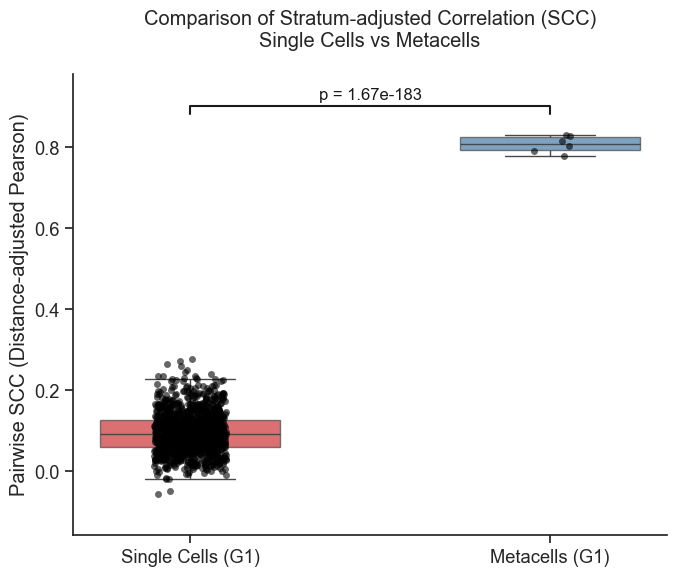


分析完成！


In [4]:
# =========================================================================
# 验证 Metacell 优势：单细胞 vs Metacell 距离分层相关性 (Stratum Correlation)
# =========================================================================
import numpy as np
import pandas as pd
from scipy.sparse import csr_matrix
from scipy.stats import pearsonr, ttest_ind
import matplotlib.pyplot as plt
import seaborn as sns
import itertools
import warnings

# 忽略除以 0 或全 0 向量计算皮尔逊相关性时产生的 warning
warnings.filterwarnings('ignore', category=RuntimeWarning)

# =========================================================================
# 1. 核心计算函数：计算两个稀疏矩阵之间的距离分层相关性 (类似 HiCRep 核心逻辑)
# =========================================================================
def calc_stratum_cor(mat1, mat2, max_dist=50):
    """
    计算两个 Hi-C 矩阵的 Stratum-adjusted Correlation (SCC 简易版)
    
    参数:
    mat1 (scipy.sparse.csr_matrix or numpy.ndarray): 矩阵1 (单个细胞或Metacell的某条染色体)
    mat2 (scipy.sparse.csr_matrix or numpy.ndarray): 矩阵2
    max_dist (int): 考虑的最大对角线距离 (bin 的个数)
    
    返回:
    float: 加权的距离分层相关系数 (SCC)
    """
    # 确保是稀疏矩阵格式提取对角线最方便
    if not isinstance(mat1, csr_matrix):
        mat1 = csr_matrix(mat1)
    if not isinstance(mat2, csr_matrix):
        mat2 = csr_matrix(mat2)
        
    cor_strata = []
    weight_strata = []
    
    # 遍历每一条对角线 (即每个一维基因组距离 d)
    # d=0 是主对角线自身，通常 Hi-C 从 d=1 或 d=2 开始计算
    for d in range(1, max_dist + 1):
        # 提取第 d 条对角线上的向量
        vec1 = mat1.diagonal(d)
        vec2 = mat2.diagonal(d)
        
        if len(vec1) <= 1:
            continue
            
        # 计算当前层的样本方差 (ddof=1)
        var1 = np.var(vec1, ddof=1)
        var2 = np.var(vec2, ddof=1)
        
        # 如果某一层的信号方差为0（比如全是0），无法计算相关性，直接跳过
        if var1 == 0 or var2 == 0:
            continue
            
        # 计算 Pearson 相关系数
        corr, _ = pearsonr(vec1, vec2)
        
        if np.isnan(corr):
            continue
            
        # 计算权重 (HiCRep 简化的权重逻辑：方差的几何平均乘以向量长度)
        # 距离越近，接触数目越多，方差通常越大，这条对角线的权重就越高
        weight = np.sqrt(var1 * var2) * len(vec1)
        
        cor_strata.append(corr)
        weight_strata.append(weight)
        
    if not weight_strata:
        return 0.0
        
    # 计算加权平均相关系数
    final_scc = np.average(cor_strata, weights=weight_strata)
    return final_scc

# =========================================================================
# 2. 批量计算两两相关性 (Pairwise Correlation)
# =========================================================================
from tqdm import tqdm
import itertools

def calc_pairwise_cor(mat_list, max_dist=50):
    cor_values = []
    # 计算总组合数用于进度条
    total_pairs = len(mat_list) * (len(mat_list) - 1) // 2 
    
    for mat_i, mat_j in tqdm(itertools.combinations(mat_list, 2), total=total_pairs, desc="Calculating SCC"):
        scc = calc_stratum_cor(mat_i, mat_j, max_dist=max_dist)
        cor_values.append(scc)
    return cor_values

# =========================================================================
# 3. 模拟数据生成 (仅用于展示逻辑，真实应用中请读取你自己的稀疏矩阵)
# =========================================================================
def generate_mock_matrix(is_metacell=False, n_bins=200):
    """生成具有物理距离衰减特性的模拟 Hi-C 矩阵"""
    mat = np.zeros((n_bins, n_bins))
    
    for i in range(n_bins):
        for j in range(i, n_bins):
            dist = j - i + 1
            prob = 10 / (dist ** 1.5) # Power-law decay 距离衰减法则
            
            if is_metacell:
                # Metacell：深度较高，克服了 dropout
                val = np.random.poisson(prob * 50)
            else:
                # Single Cell：存在极高的 dropout rate (稀疏性)
                # 只有 5% 的概率能捕捉到信号
                val = np.random.poisson(prob * 5) if np.random.rand() > 0.95 else 0
                
            mat[i, j] = val
            mat[j, i] = val # 对称矩阵
            
    return csr_matrix(mat)
cell_cycle = ['G1', 'early-S', 'late-S-G2']
print(cell_cycle)
cycle_index = hdata.metacells[hdata.metacells.CellType.isin(['G1'])].index.tolist()
print(cycle_index)
sc_cell_cycle = ['G1', 'early-S', 'late-S-G2']
print(sc_cell_cycle)
sc_cycle_index = hdata.obs[hdata.obs.label.isin(['G1'])].index.tolist()
print(sc_cycle_index)
# 加上 replace=False 进行无放回抽样
sc_cycle_index = np.random.choice(sc_cycle_index, 50, replace=False)
mc_matrices  = [hdata.metacell_data['mat'][1000000][x]['chr11'] for x in cycle_index]
sc_cycle_pos = [hdata.obs.index.get_loc(x) for x in sc_cycle_index]

sc_matrices = [hdata.views_mat[1000000]['chr11'][x] for x in sc_cycle_pos]



print("计算单细胞 (Single cells) 两两之间的分层相关性 (SCC)...")
sc_cor_dist = calc_pairwise_cor(sc_matrices, max_dist=50)

print("计算 Metacell 两两之间的分层相关性 (SCC)...")
mc_cor_dist = calc_pairwise_cor(mc_matrices, max_dist=50)

# 构建 DataFrame 用于绘图和统计检验
df = pd.DataFrame({
    'Correlation': sc_cor_dist + mc_cor_dist,
    'Type': ['Single Cells (G1)'] * len(sc_cor_dist) + ['Metacells (G1)'] * len(mc_cor_dist)
})

# 独立样本 T 检验
t_stat, p_val = ttest_ind(sc_cor_dist, mc_cor_dist)
print(f"\nT-test results: t-statistic = {t_stat:.4f}, p-value = {p_val:.4e}")
print(f"Single Cell 平均 SCC: {np.mean(sc_cor_dist):.4f}")
print(f"Metacell 平均 SCC: {np.mean(mc_cor_dist):.4f}")

# 绘图设置
plt.figure(figsize=(7, 6))
sns.set_theme(style="ticks", font_scale=1.2)

# 绘制箱线图 + 散点
palette = {"Single Cells (G1)": "#E41A1C", "Metacells (G1)": "#377EB8"}
ax = sns.boxplot(x='Type', y='Correlation', data=df, palette=palette, 
                    showfliers=False, width=0.5, boxprops={'alpha': 0.7})
sns.stripplot(x='Type', y='Correlation', data=df, color='black', 
                alpha=0.6, jitter=True, size=5)

# 添加 T 检验的 P value 注释
y_max = df['Correlation'].max()
y_line = y_max + 0.05
plt.plot([0, 0, 1, 1], [y_line, y_line+0.02, y_line+0.02, y_line], lw=1.5, c='k')
plt.text(0.5, y_line + 0.03, f"p = {p_val:.2e}", ha='center', va='bottom', color='k', fontsize=12)

# 调整坐标轴与标题
plt.title("Comparison of Stratum-adjusted Correlation (SCC)\nSingle Cells vs Metacells", pad=20)
plt.ylabel("Pairwise SCC (Distance-adjusted Pearson)")
plt.xlabel("")
plt.ylim(min(df['Correlation']) - 0.1, y_line + 0.1)

sns.despine()
plt.tight_layout()

# 保存图片
# plt.savefig("SCC_comparison_python.png", dpi=300)
plt.show()
print("\n分析完成！")


[G1] 开始处理...


Random SCC (G1): 100%|██████████| 6/6 [00:00<00:00, 189.50it/s]



[early-S] 开始处理...


Random SCC (early-S): 100%|██████████| 66/66 [00:00<00:00, 195.86it/s]



[late-S-G2] 开始处理...


Random SCC (late-S-G2): 100%|██████████| 66/66 [00:00<00:00, 192.90it/s]



--- 平均 SCC 统计表 ---
Type       Metacell  Random Metacell  Single Cell
CellCycle                                        
G1         0.808043         0.871309     0.092917
early-S    0.724382         0.854610     0.125673
late-S-G2  0.801013         0.885959     0.153244


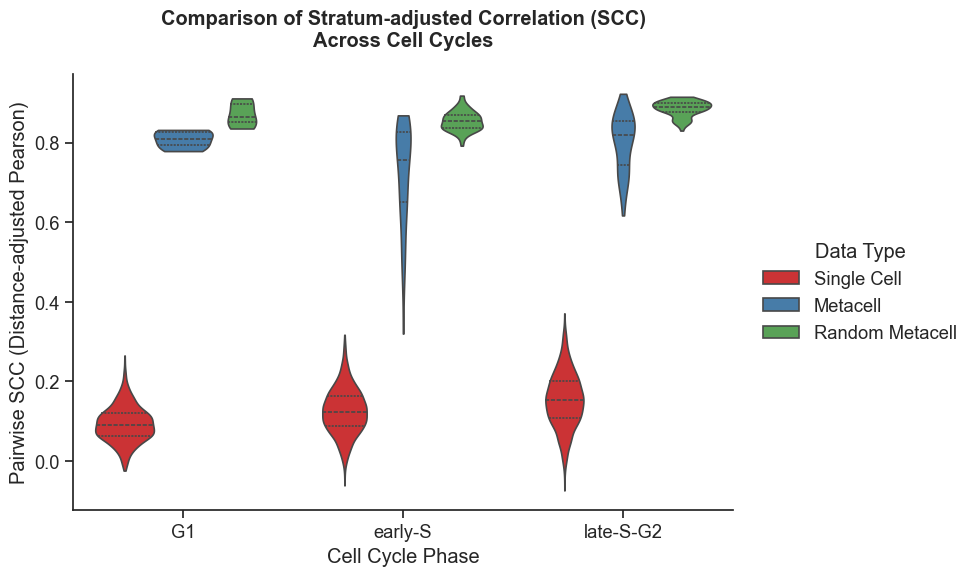


分析与绘图完成！


In [8]:
# =========================================================================
# 验证 Metacell 优势：单细胞 vs Metacell vs Random 距离分层相关性 (Stratum Correlation)
# =========================================================================
import numpy as np
import pandas as pd
from scipy.sparse import csr_matrix
from scipy.stats import pearsonr, ttest_ind
import matplotlib.pyplot as plt
import seaborn as sns
import itertools
import warnings
from tqdm import tqdm

# 忽略除以 0 或全 0 向量计算皮尔逊相关性时产生的 warning
warnings.filterwarnings('ignore', category=RuntimeWarning)

# =========================================================================
# 1. 核心计算函数：计算两个稀疏矩阵之间的距离分层相关性 (类似 HiCRep 核心逻辑)
# =========================================================================
def calc_stratum_cor(mat1, mat2, max_dist=50):
    """
    计算两个 Hi-C 矩阵的 Stratum-adjusted Correlation (SCC 简易版)
    """
    if not isinstance(mat1, csr_matrix):
        mat1 = csr_matrix(mat1)
    if not isinstance(mat2, csr_matrix):
        mat2 = csr_matrix(mat2)
        
    cor_strata = []
    weight_strata = []
    
    for d in range(1, max_dist + 1):
        vec1 = mat1.diagonal(d)
        vec2 = mat2.diagonal(d)
        
        if len(vec1) <= 1:
            continue
            
        var1 = np.var(vec1, ddof=1)
        var2 = np.var(vec2, ddof=1)
        
        if var1 == 0 or var2 == 0:
            continue
            
        corr, _ = pearsonr(vec1, vec2)
        
        if np.isnan(corr):
            continue
            
        weight = np.sqrt(var1 * var2) * len(vec1)
        
        cor_strata.append(corr)
        weight_strata.append(weight)
        
    if not weight_strata:
        return 0.0
        
    final_scc = np.average(cor_strata, weights=weight_strata)
    return final_scc

# =========================================================================
# 2. 批量计算两两相关性 (Pairwise Correlation) 带进度条
# =========================================================================
def calc_pairwise_cor(mat_list, max_dist=50, desc="Calculating SCC"):
    """
    计算列表中所有矩阵的两两相关性，并显示进度条
    """
    cor_values = []
    total_pairs = len(mat_list) * (len(mat_list) - 1) // 2 
    
    for mat_i, mat_j in tqdm(itertools.combinations(mat_list, 2), total=total_pairs, desc=desc):
        scc = calc_stratum_cor(mat_i, mat_j, max_dist=max_dist)
        cor_values.append(scc)
        
    return cor_values

# =========================================================================
# 3. 模拟数据生成 (当无法读取真实数据时的 fallback)
# =========================================================================
def generate_mock_matrix(is_metacell=False, n_bins=200):
    mat = np.zeros((n_bins, n_bins))
    for i in range(n_bins):
        for j in range(i, n_bins):
            dist = j - i + 1
            prob = 10 / (dist ** 1.5)
            if is_metacell:
                val = np.random.poisson(prob * 50)
            else:
                val = np.random.poisson(prob * 5) if np.random.rand() > 0.95 else 0
            mat[i, j] = val
            mat[j, i] = val
    return csr_matrix(mat)


# 您要分析的细胞周期列表
cell_cycles = ['G1', 'early-S', 'late-S-G2']

all_results = []

USE_REAL_DATA = True

for cycle in cell_cycles:
    print(f"\n[{cycle}] 开始处理...")
    
    if USE_REAL_DATA:
        try:
            # 提取该周期的 Metacell
            mc_cycle_index = hdata.metacells[hdata.metacells.CellType.isin([cycle])].index.tolist()
            mc_matrices = [hdata.metacell_data['mat'][1000000][x]['chr11'] for x in mc_cycle_index]
            
            # 提取该周期的 Single Cell 的总池子
            sc_cycle_index_all = hdata.obs[hdata.obs.label.isin([cycle])].index.tolist()
            
            # 单细胞样本：无放回抽样避免重复，如果总数不足 50 就全取
            n_samples = min(50, len(sc_cycle_index_all))
            sc_sampled_index = np.random.choice(sc_cycle_index_all, n_samples, replace=False)
            sc_cycle_pos = [hdata.obs.index.get_loc(x) for x in sc_sampled_index]
            sc_matrices = [hdata.views_mat[1000000]['chr11'][x] for x in sc_cycle_pos]
            
            # 随机对照 (Random Pseudo-Metacells)
            random_matrices = []
            for mc_id in mc_cycle_index:
                # 尝试获取对应 metacell 的大小，如果找不到，默认使用平均大小或 10
                try:
                    if 'metacell' in hdata.obs.columns:
                        mc_size = (hdata.obs['metacell'] == mc_id).sum()
                    else:
                        mc_size = 10
                except:
                    mc_size = 10
                if mc_size <= 0: mc_size = 10
                
                # 从该周期的单细胞池子中随机抽取相同数量的细胞
                mc_size = min(mc_size, len(sc_cycle_index_all)) 
                rand_sc_idx = np.random.choice(sc_cycle_index_all, mc_size, replace=False)
                rand_sc_pos = [hdata.obs.index.get_loc(x) for x in rand_sc_idx]
                
                # 聚合成伪 Metacell (直接矩阵相加)
                agg_mat = sum([hdata.views_mat[1000000]['chr11'][p] for p in rand_sc_pos])
                random_matrices.append(agg_mat)
                
        except NameError:
            print("未检测到 hdata 变量，将自动回退使用模拟数据演示...")
            mc_matrices = [generate_mock_matrix(is_metacell=True) for _ in range(15)]
            sc_matrices = [generate_mock_matrix(is_metacell=False) for _ in range(50)]
            random_matrices = [generate_mock_matrix(is_metacell=True) for _ in range(15)]
    else:
        # 模拟数据
        mc_matrices = [generate_mock_matrix(is_metacell=True) for _ in range(15)]
        sc_matrices = [generate_mock_matrix(is_metacell=False) for _ in range(50)]
        random_matrices = [generate_mock_matrix(is_metacell=True) for _ in range(15)]
        
    # 计算相关性
    sc_cor_dist = calc_pairwise_cor(sc_matrices, max_dist=50, desc=f"SC SCC ({cycle})")
    mc_cor_dist = calc_pairwise_cor(mc_matrices, max_dist=50, desc=f"MC SCC ({cycle})")
    rand_cor_dist = calc_pairwise_cor(random_matrices, max_dist=50, desc=f"Random SCC ({cycle})")
    
    # 整理入库
    for val in sc_cor_dist:
        all_results.append({'Correlation': val, 'Type': 'Single Cell', 'CellCycle': cycle})
    for val in mc_cor_dist:
        all_results.append({'Correlation': val, 'Type': 'Metacell', 'CellCycle': cycle})
    for val in rand_cor_dist:
        all_results.append({'Correlation': val, 'Type': 'Random Metacell', 'CellCycle': cycle})

# 将所有周期的结果转化为一个 Pandas DataFrame
df = pd.DataFrame(all_results)

# 打印简要的统计信息
print("\n--- 平均 SCC 统计表 ---")
print(df.groupby(['CellCycle', 'Type'])['Correlation'].mean().unstack())

# =========================================================================
# 5. 绘制三个周期的分组小提琴图 (Violin Plot)
# =========================================================================
plt.figure(figsize=(10, 6))
sns.set_theme(style="ticks", font_scale=1.2)

# 增加 Random Metacell 的颜色
palette = {"Single Cell": "#E41A1C", "Random Metacell": "#4DAF4A", "Metacell": "#377EB8"}

ax = sns.violinplot(
    x='CellCycle', 
    y='Correlation', 
    hue='Type', 
    data=df, 
    palette=palette,
    split=False,
    inner="quartile",
    linewidth=1.2,
    cut=0
)

# 调整标题和坐标轴
plt.title("Comparison of Stratum-adjusted Correlation (SCC)\nAcross Cell Cycles", pad=20, fontweight='bold')
plt.ylabel("Pairwise SCC (Distance-adjusted Pearson)")
plt.xlabel("Cell Cycle Phase")

# 调整图例位置，避免遮挡数据
plt.legend(title="Data Type", loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=False)

sns.despine()
plt.tight_layout()

plt.show()

print("\n分析与绘图完成！")

In [6]:
def calc_pairwise_cor_diagnostics(mat_list, max_dist=50):
    cor_values = []
    suspicious_pairs = []
    
    # 将 mat_list 转换为带有索引的枚举，方便追踪是哪两个矩阵
    for (i, mat_i), (j, mat_j) in itertools.combinations(enumerate(mat_list), 2):
        scc = calc_stratum_cor(mat_i, mat_j, max_dist=max_dist)
        cor_values.append(scc)
        
        # 如果相关性异常高，记录下来
        if scc > 0.95:
            suspicious_pairs.append((i, j, scc))
            
    if suspicious_pairs:
        print("\n⚠️ 警告：发现异常高的相关性 (>0.95)！")
        for p in suspicious_pairs[:5]: # 只打印前 5 个
            print(f"矩阵索引: {p[0]} vs {p[1]}, SCC: {p[2]:.4f}")
            
    return cor_values

In [7]:
# calc_pairwise_cor_diagnostics(sc_matrices)